In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling


In [2]:
df = pd.read_csv('bank.csv', delimiter=';')

In [3]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [5]:
num = [i for i in df.columns if df[i].dtypes != 'object']
cat = [i for i in df.columns if df[i].dtypes == 'object']

In [6]:
cat

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'y']

In [7]:
num

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

### Exploratory Data Analysis

#### Categorical Univariate

In [8]:
# Non graphical. 
for i in cat :
    print(f'Unique values in {i} is {df[i].unique()}')
    print(f'Number of Unique values in {i} is {df[i].nunique()}')
    print(df[i].value_counts())
    print("************************************************************")

Unique values in job is ['unemployed' 'services' 'management' 'blue-collar' 'self-employed'
 'technician' 'entrepreneur' 'admin.' 'student' 'housemaid' 'retired'
 'unknown']
Number of Unique values in job is 12
job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64
************************************************************
Unique values in marital is ['married' 'single' 'divorced']
Number of Unique values in marital is 3
marital
married     2797
single      1196
divorced     528
Name: count, dtype: int64
************************************************************
Unique values in education is ['primary' 'secondary' 'tertiary' 'unknown']
Number of Unique values in education is 4
education
secondary    2306
tertiary     1350
primary       678
unknown       187
N

### Categorical Univariate

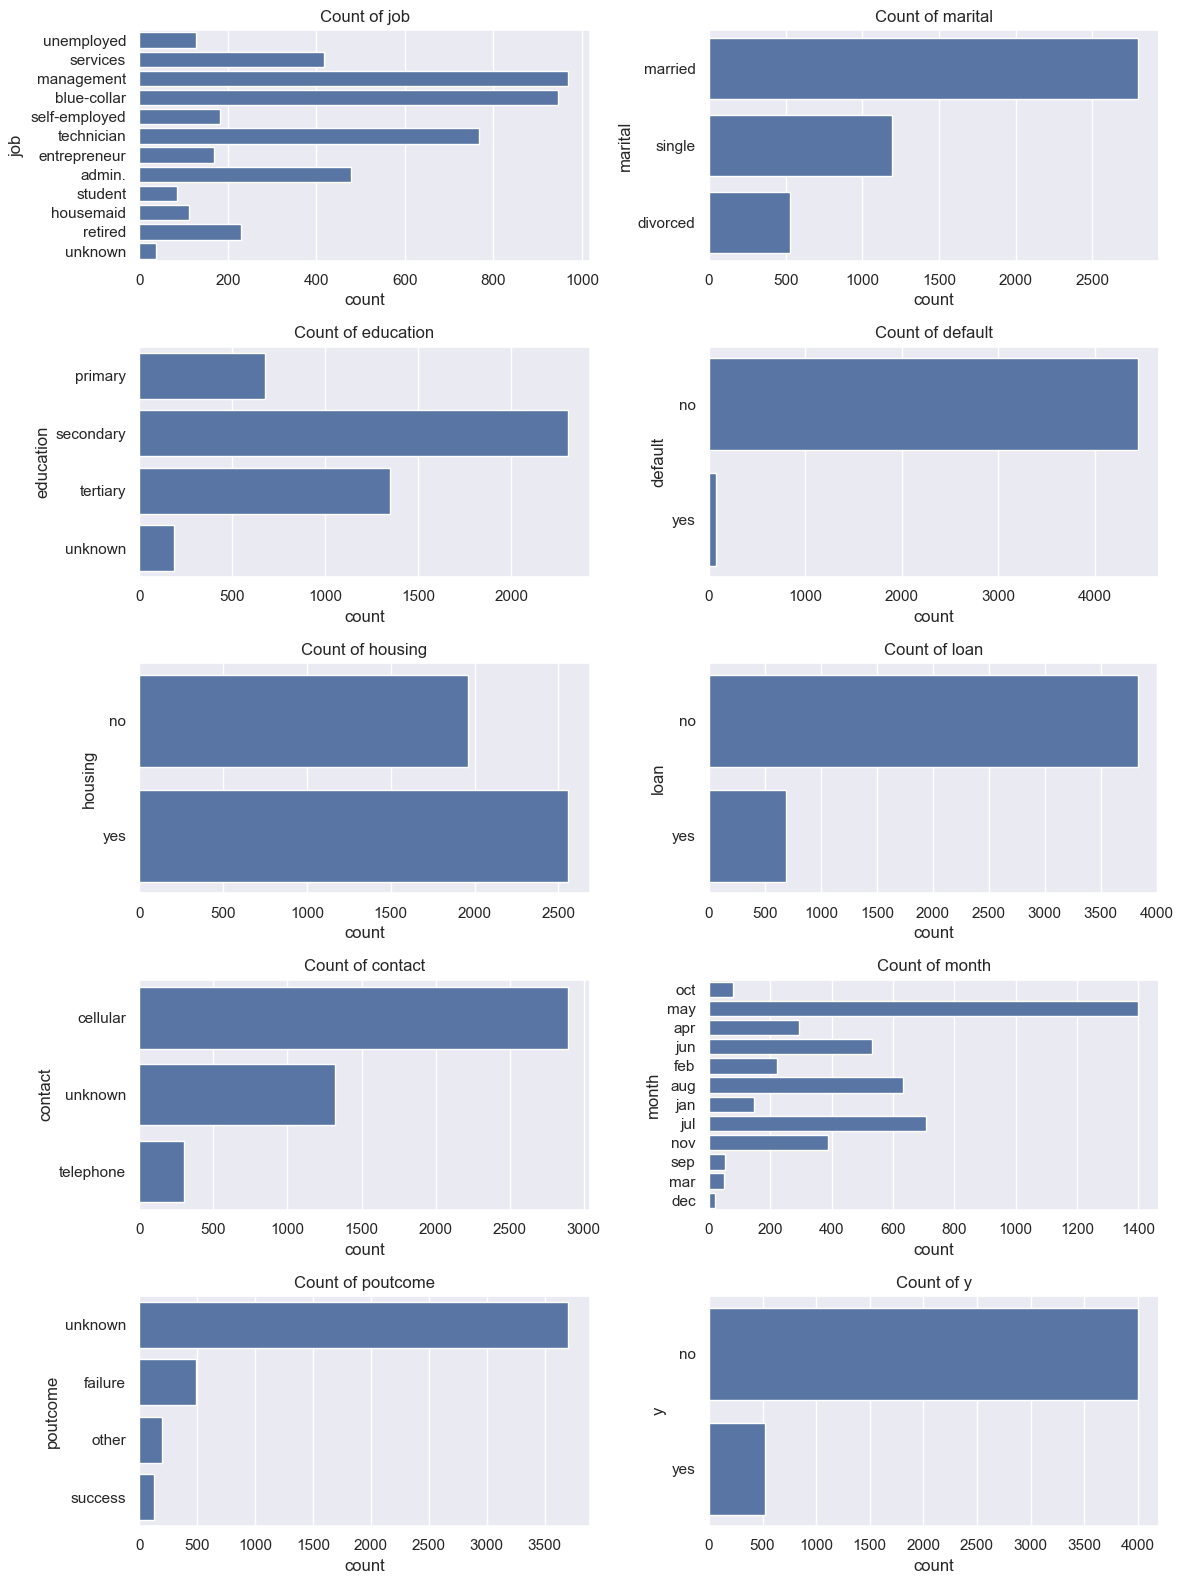

In [9]:
# Create count plot to check distribution of Categorical features
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(12, 16))
for i, col in enumerate(cat):
    row_index = i // 2  # Calculate the row index
    col_index = i % 2   # Calculate the column index
    sns.countplot(data=df, y=col, ax=axs[row_index, col_index])
    axs[row_index, col_index].set_title(f"Count of {col}")
plt.tight_layout()
plt.show()

In [10]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


## Univariate Analysis

#### Kernel Density Estimation (KDE) of Numerical Features

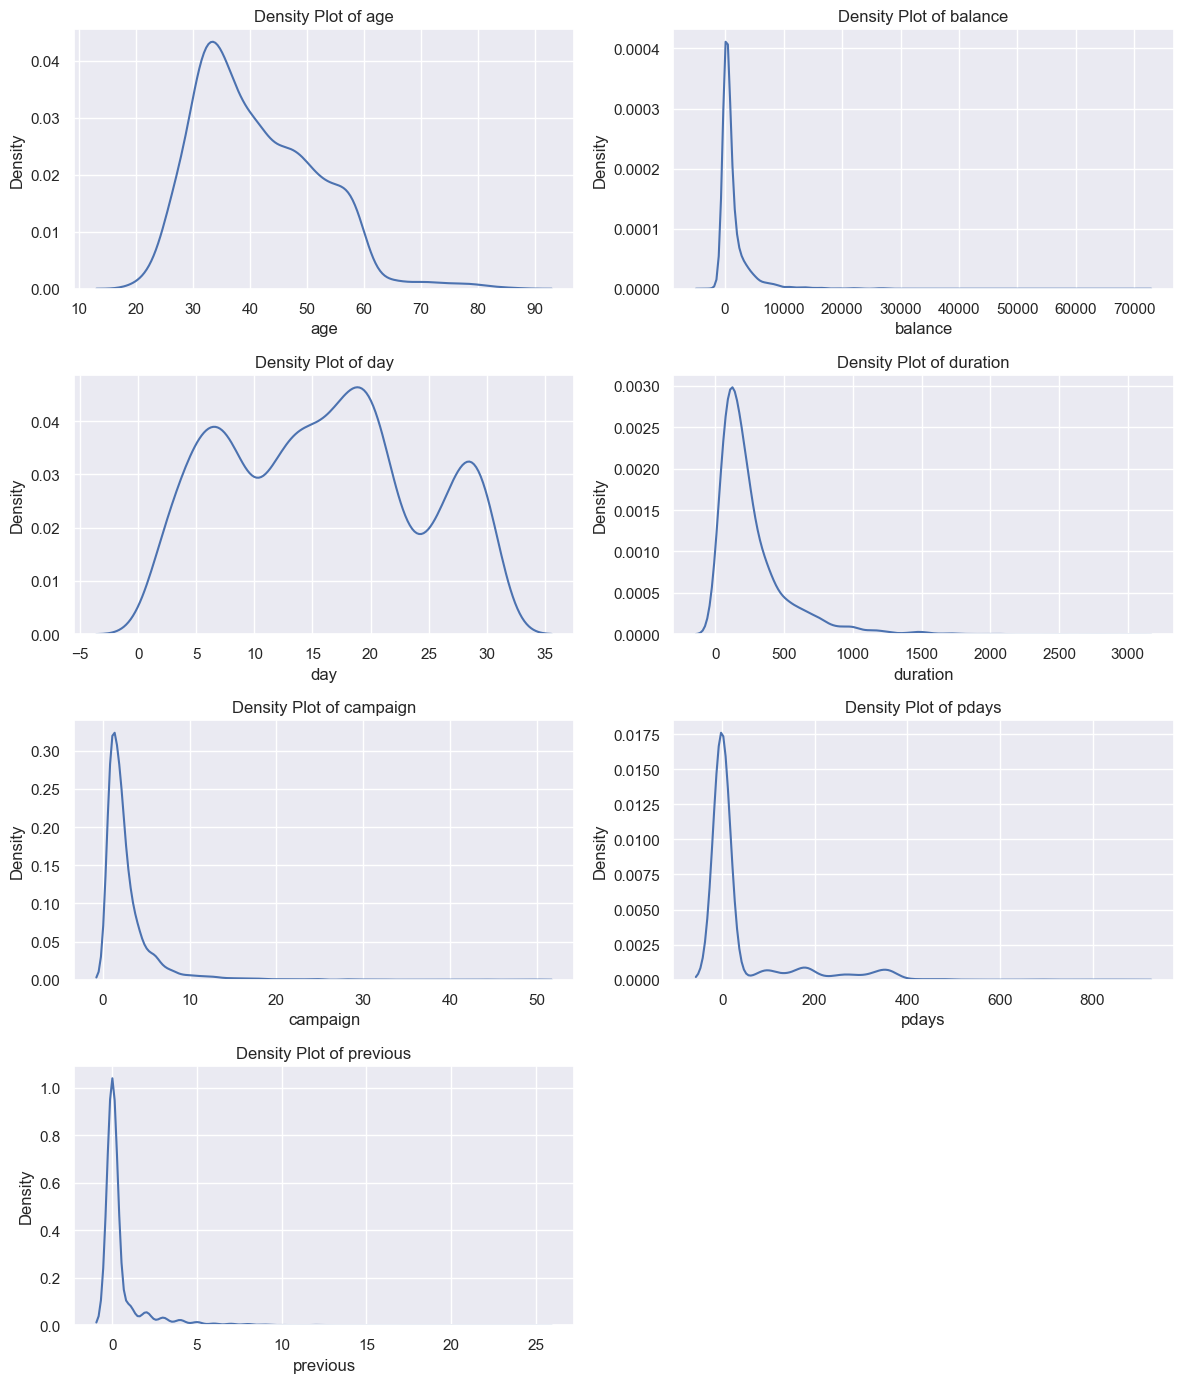

In [11]:
# Calculate the number of rows and columns for the subplots based on the number of features
n_cols = 2
n_rows = (len(num) + n_cols - 1) // n_cols
fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 14))
axs = axs.flatten()

for i, col in enumerate(num):
    sns.kdeplot(data=df, x=col, ax=axs[i])
    axs[i].set_title(f"Density Plot of {col}") 

for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()


#### Histograms with Kernel Density Estimates for Numerical Variables

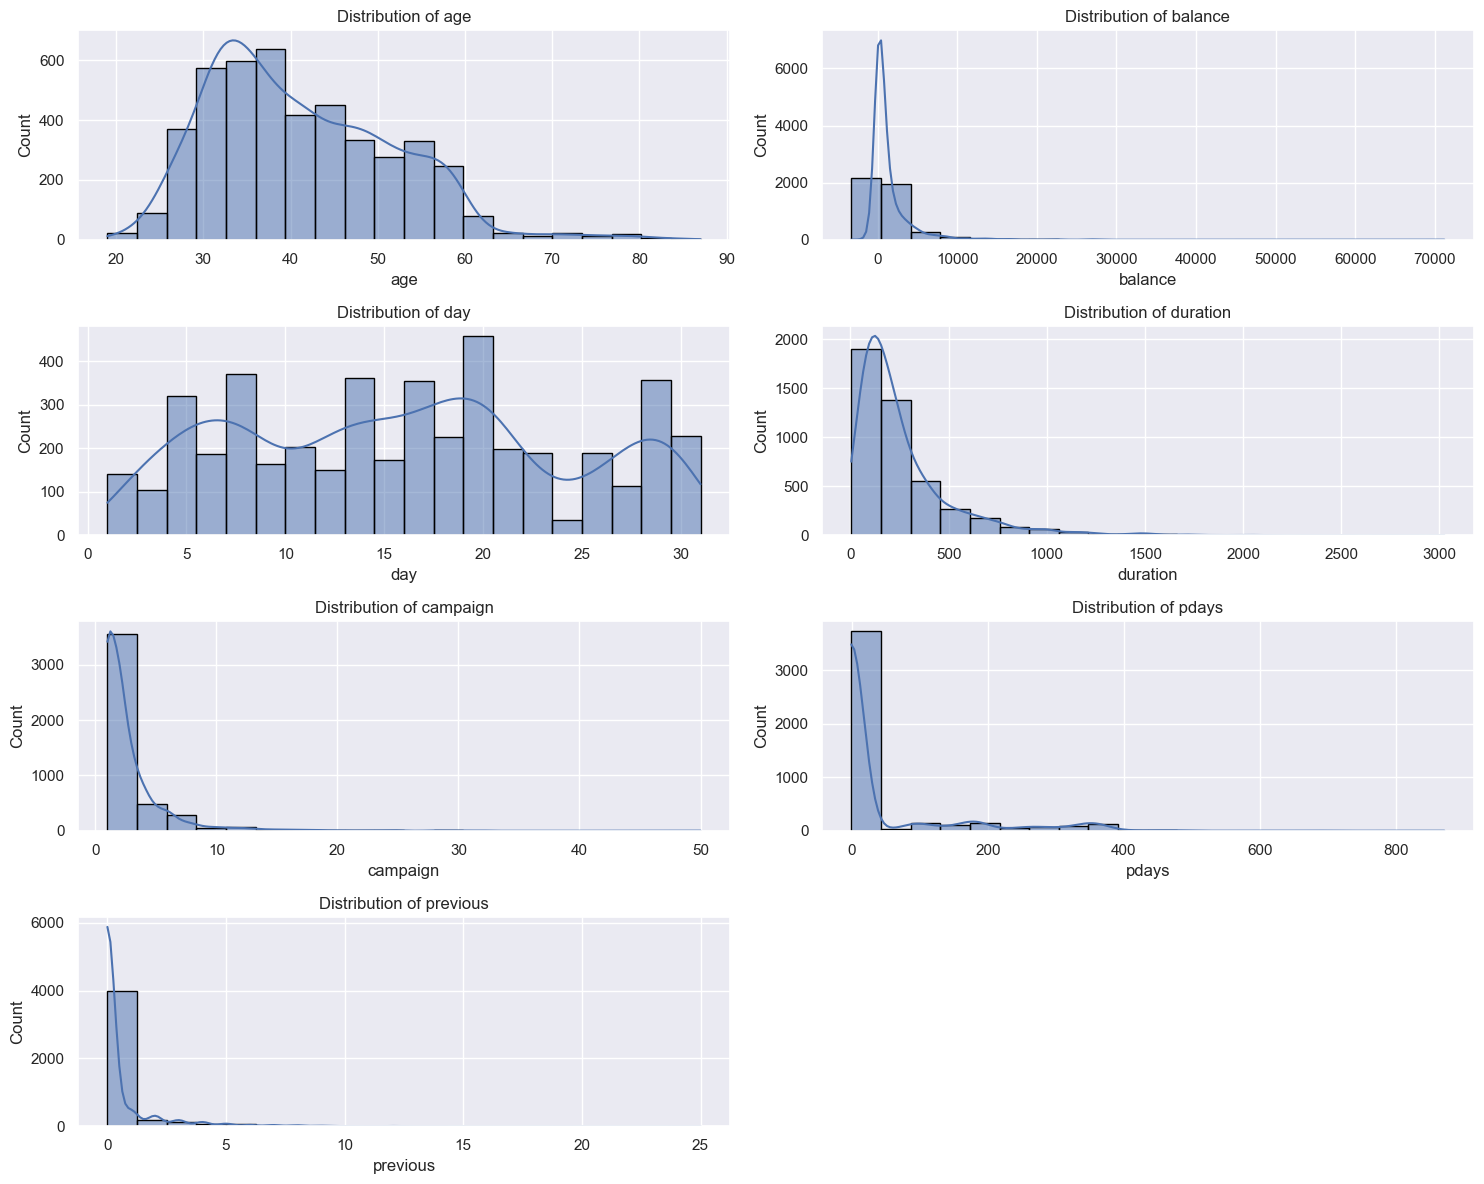

In [12]:
plt.figure(figsize=(15, 12))

for i, col in enumerate(num, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[col], kde=True, edgecolor='black', bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col) 
    plt.ylabel('Count') 

plt.tight_layout()
plt.show()


#### Box Plots of Numerical Features

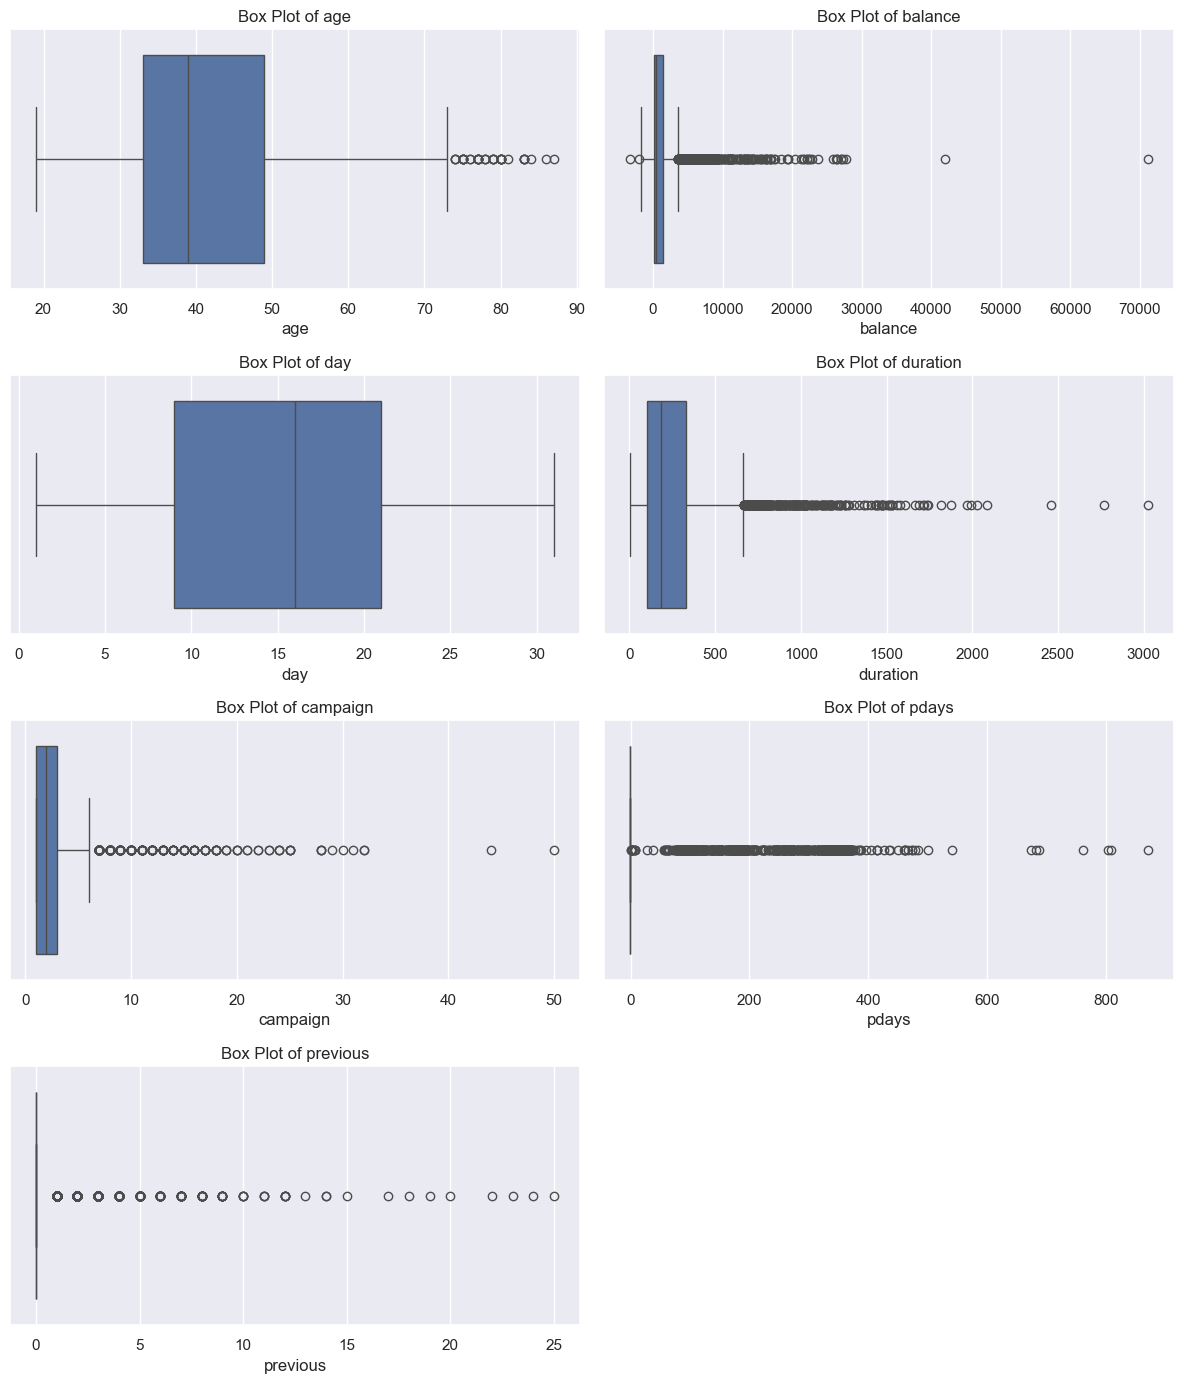

In [13]:
num_features = len(num) 
n_cols = 2 
n_rows = (num_features + n_cols - 1) // n_cols

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 14))
axs = axs.flatten()

for i, col in enumerate(num):
    sns.boxplot(data=df, x=col, ax=axs[i])
    axs[i].set_title(f"Box Plot of {col}")

# Remove any unused subplots (if any)
for j in range(i + 1, len(axs)):
    axs[j].axis('off')
    
plt.tight_layout()
plt.show()



## Bivariate Analysis

#### Average Counts of Numerical Features by Target Variable(y)

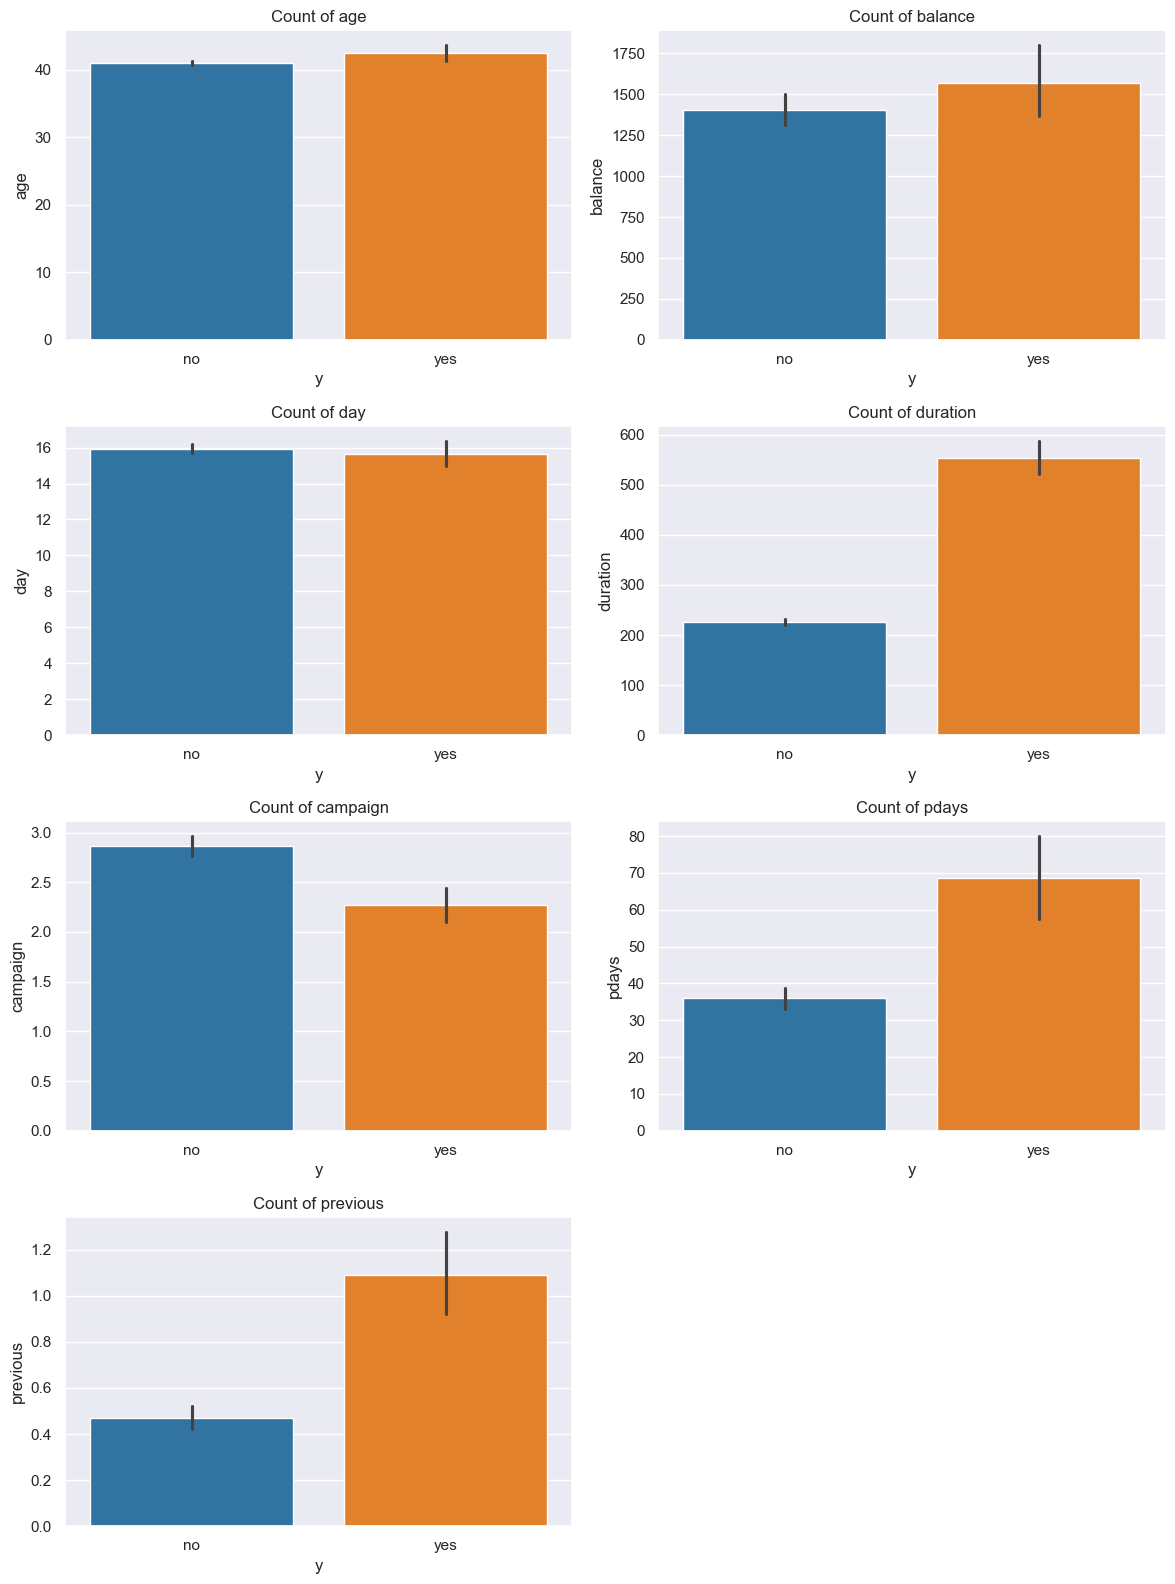

In [14]:
custom_palette = ["#1f77b4", "#ff7f0e"]

n_cols = 2 
n_rows = (len(num) + n_cols - 1) // n_cols
fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, n_rows * 4))
axs = axs.flatten()

for i, col in enumerate(num):
    sns.barplot(data=df, x='y', y=col, hue='y', ax=axs[i], palette=custom_palette, dodge=False)
    axs[i].set_title(f"Count of {col}")
    if axs[i].legend_:
        axs[i].legend_.remove()

# Remove any unused subplots (if any)
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

#### Box Plots of Numerical Features by Job Category

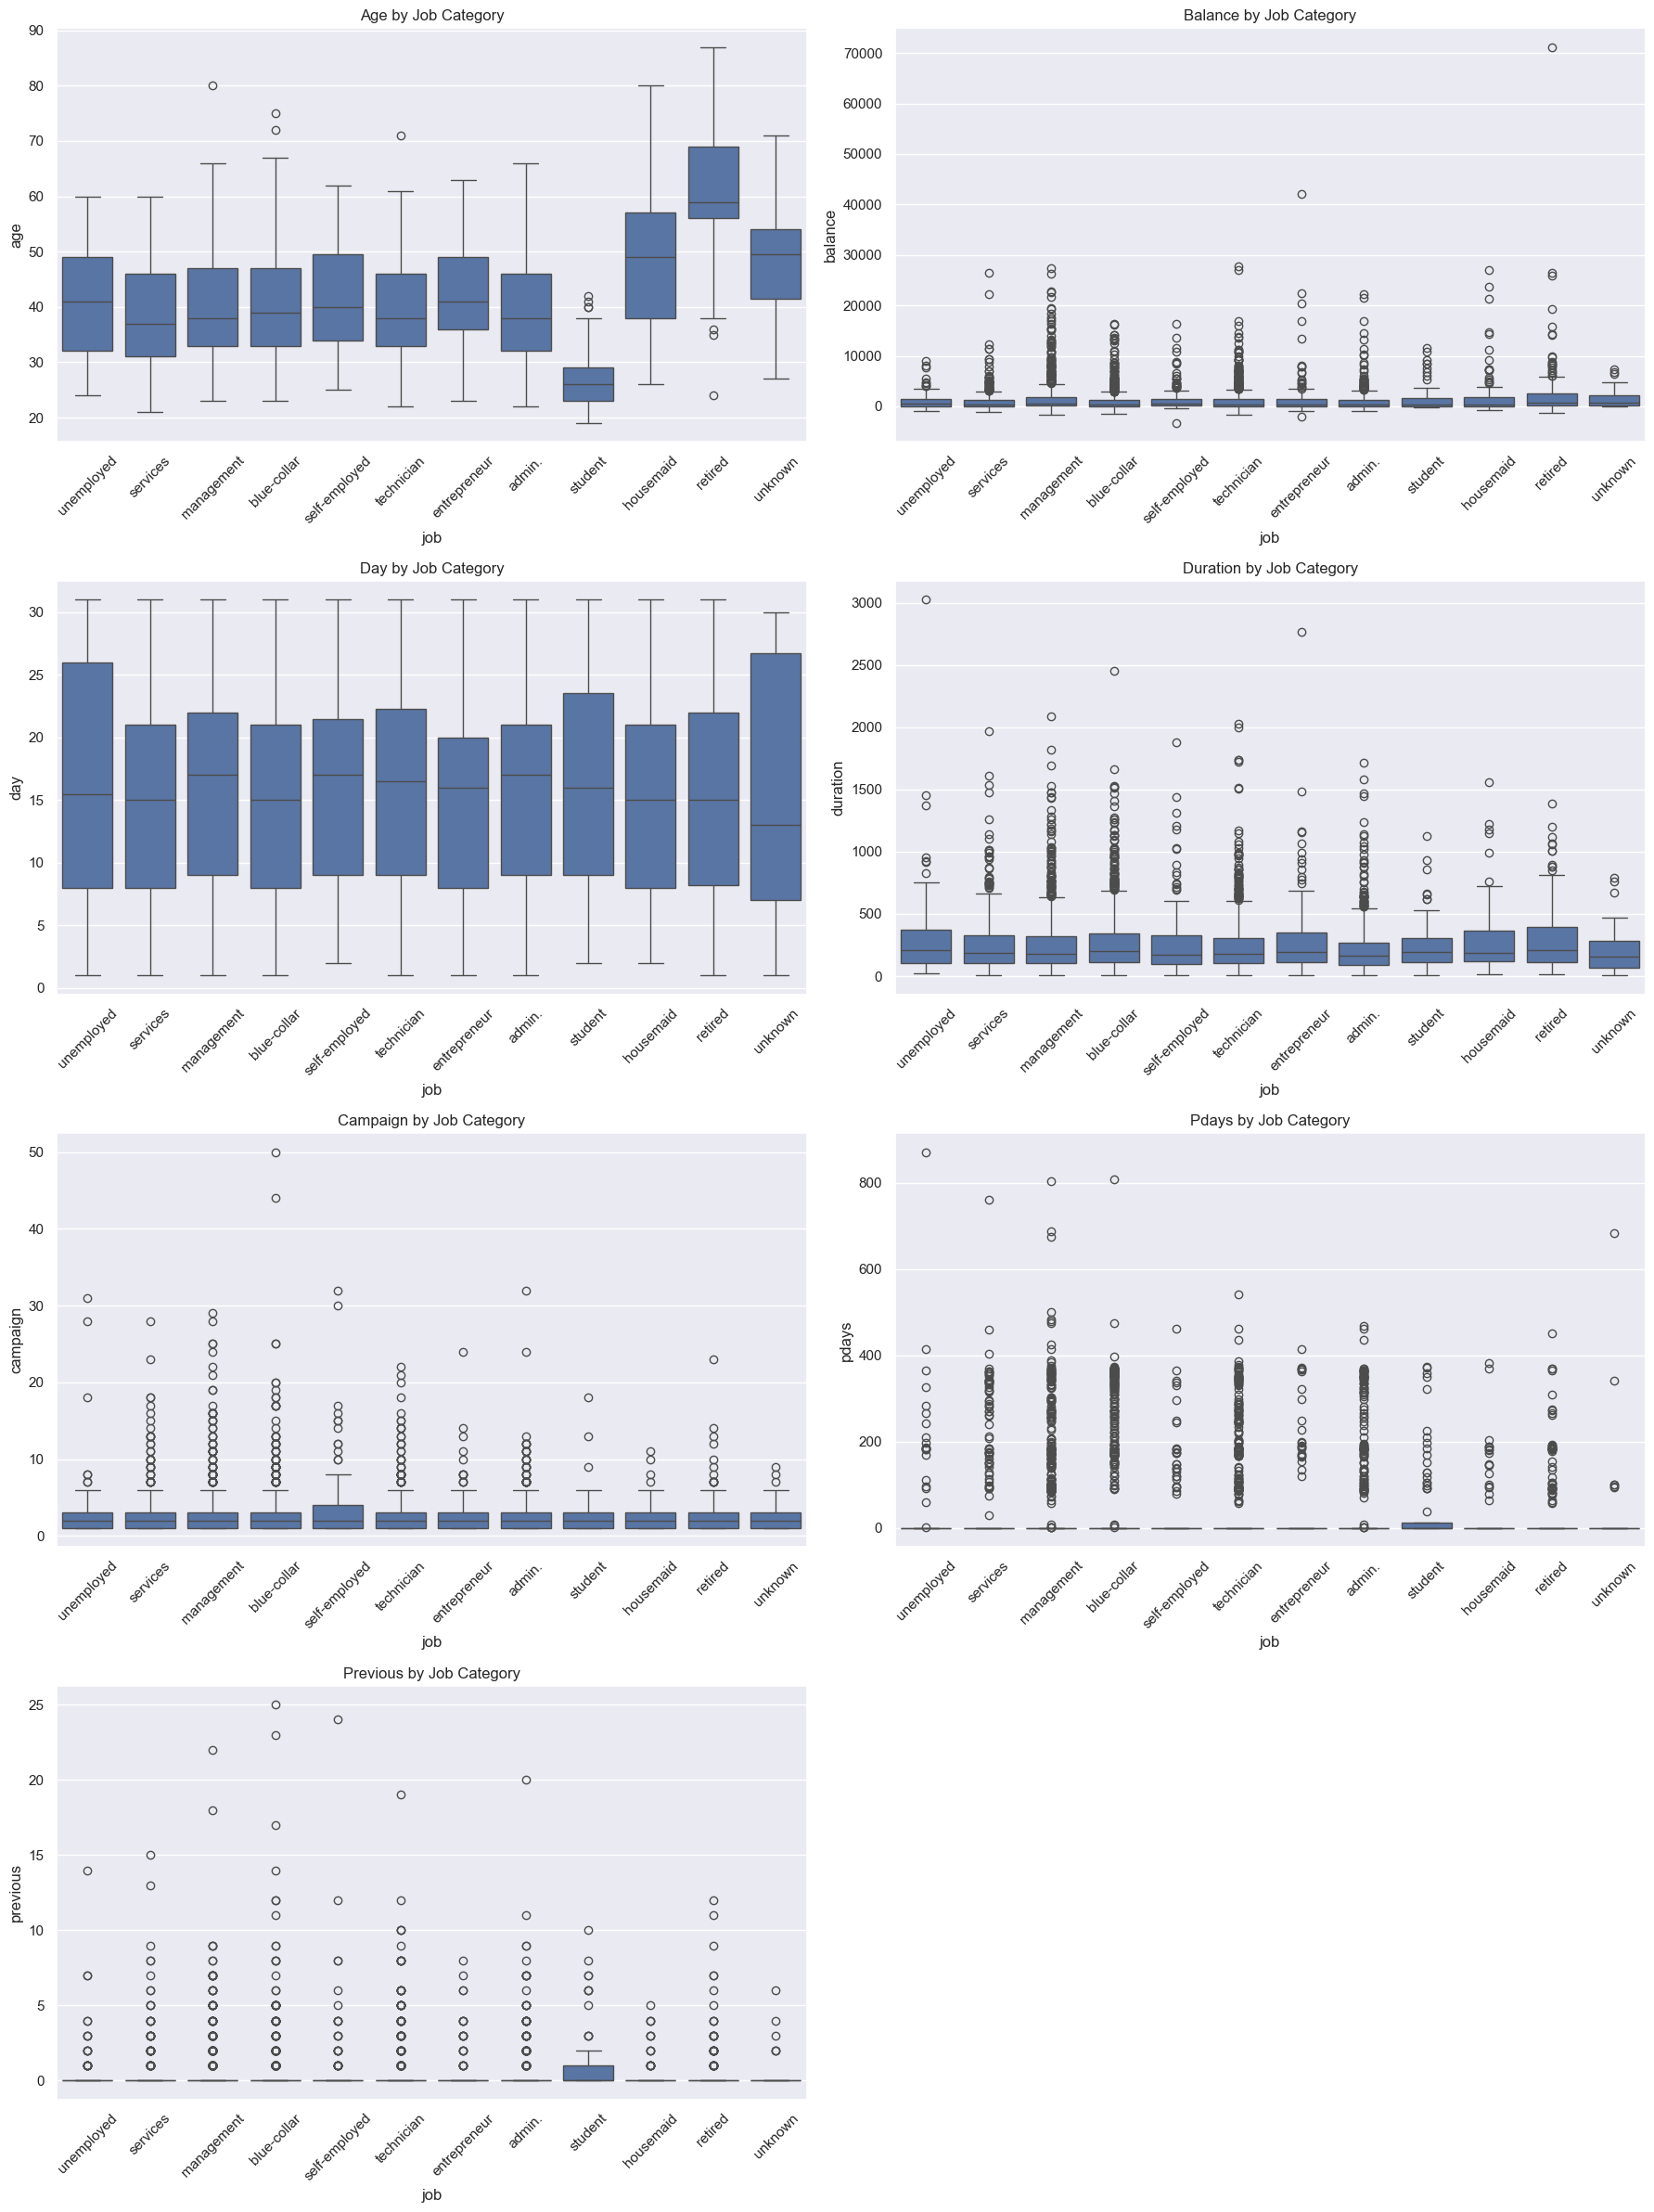

In [15]:
n_cols = 2
n_rows = (len(num) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 6))
axes = axes.flatten()

for i, col in enumerate(num):
    sns.boxplot(x='job', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col.capitalize()} by Job Category')
    axes[i].tick_params(axis='x', rotation=45) 

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Cross-Tabulation of Categorical Variables with Target Variable (y)

In [16]:
for col in ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']:
    crosstab = pd.crosstab(df[col], df['y'])
    print(f"\nCross-tabulation of {col} with target (y):")
    print(crosstab)


Cross-tabulation of job with target (y):
y               no  yes
job                    
admin.         420   58
blue-collar    877   69
entrepreneur   153   15
housemaid       98   14
management     838  131
retired        176   54
self-employed  163   20
services       379   38
student         65   19
technician     685   83
unemployed     115   13
unknown         31    7

Cross-tabulation of marital with target (y):
y           no  yes
marital            
divorced   451   77
married   2520  277
single    1029  167

Cross-tabulation of education with target (y):
y            no  yes
education           
primary     614   64
secondary  2061  245
tertiary   1157  193
unknown     168   19

Cross-tabulation of default with target (y):
y          no  yes
default           
no       3933  512
yes        67    9

Cross-tabulation of housing with target (y):
y          no  yes
housing           
no       1661  301
yes      2339  220

Cross-tabulation of loan with target (y):
y       no  yes

#### Heatmap Analysis of Categorical Variables with Target (y)

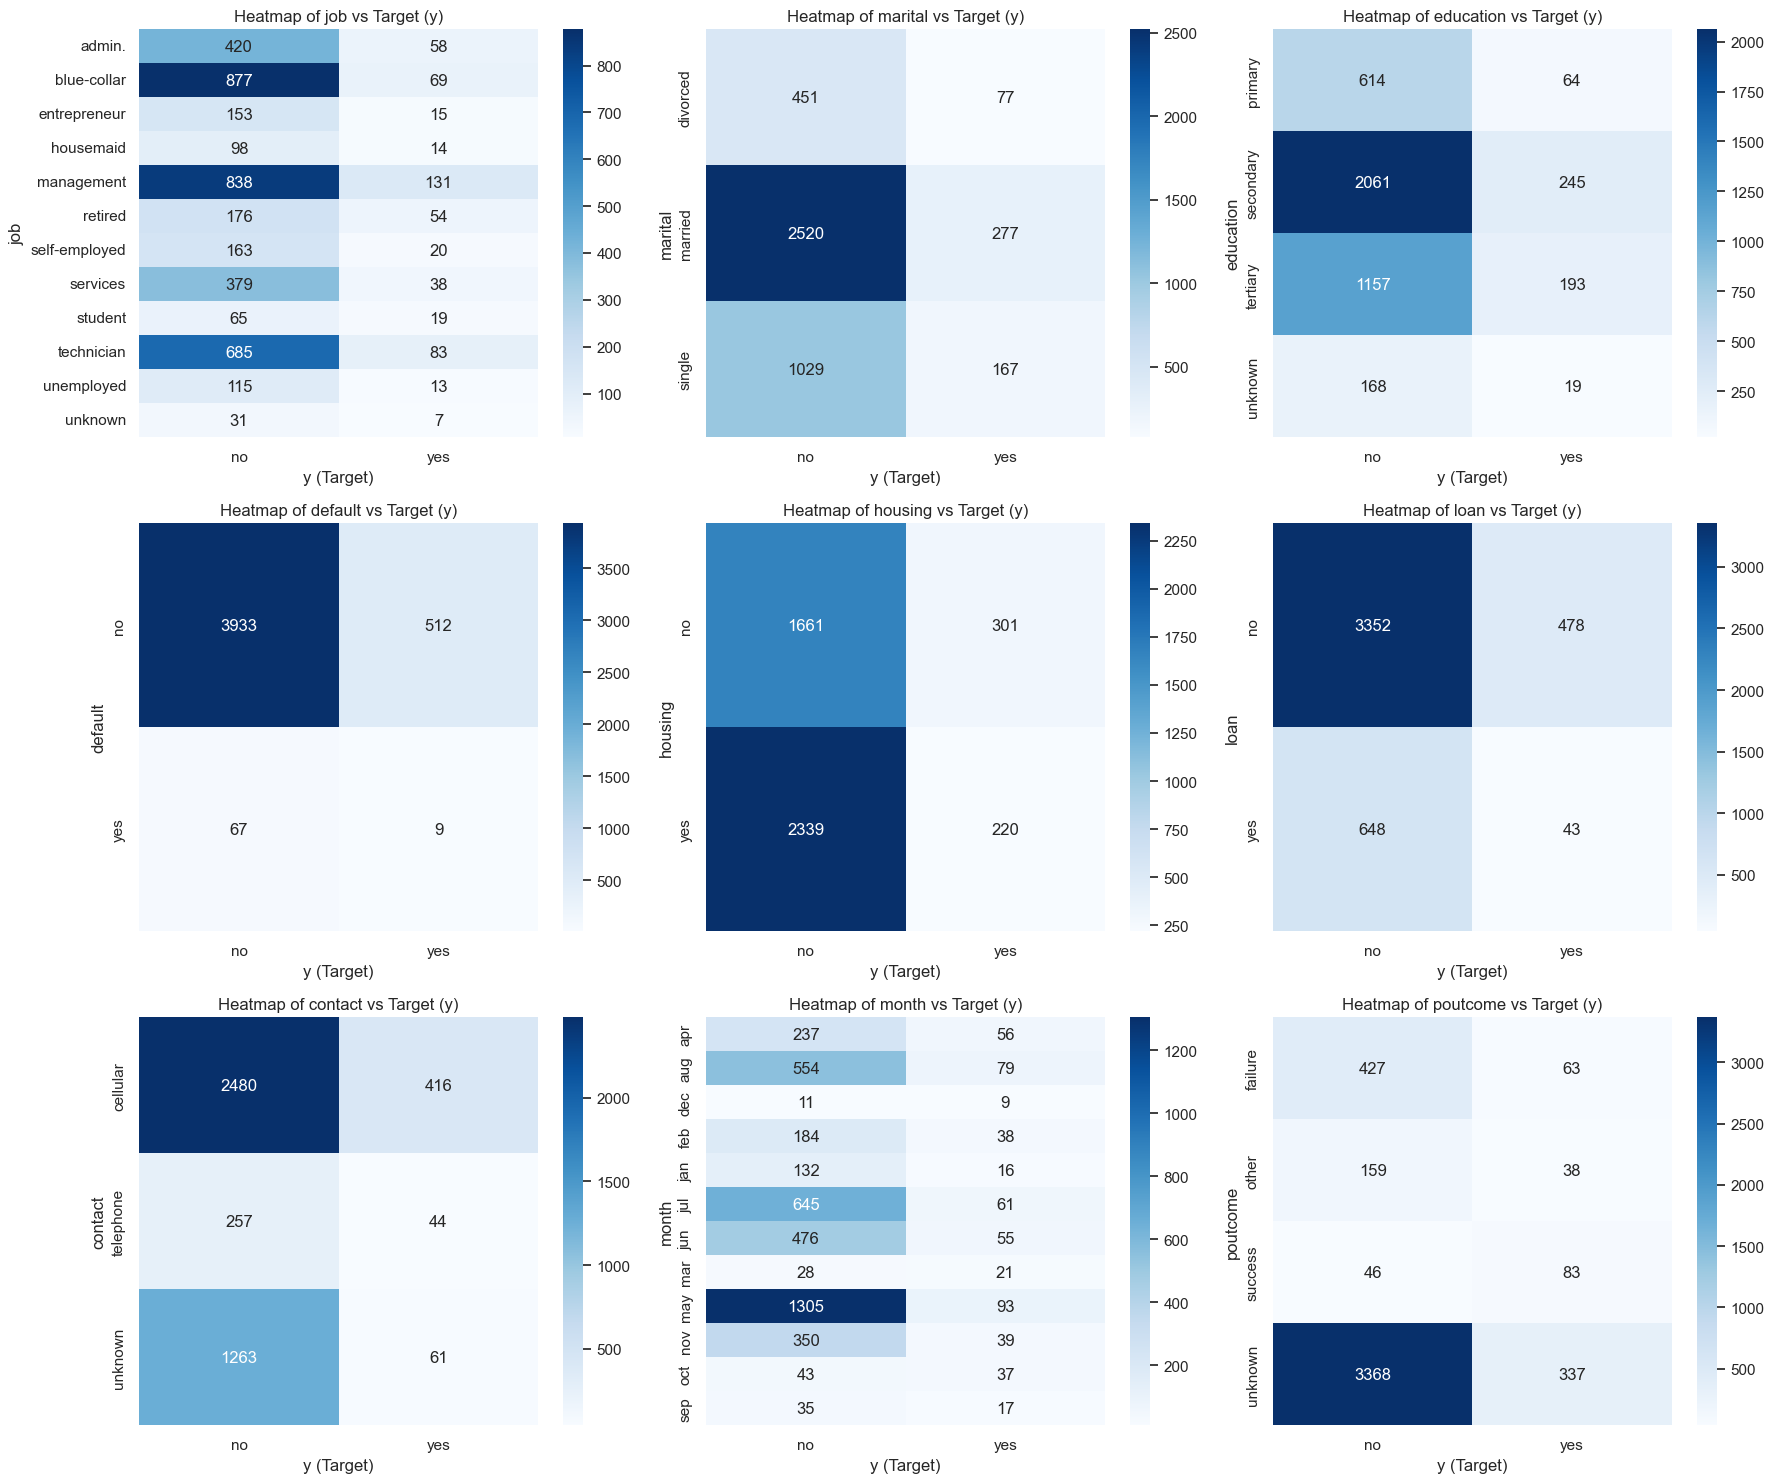

In [17]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols 
fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axs = axs.flatten()

# Loop through each categorical column and plot the heatmap
for i, col in enumerate(categorical_cols):
    crosstab = pd.crosstab(df[col], df['y'])
    sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', ax=axs[i])
    axs[i].set_title(f'Heatmap of {col} vs Target (y)')
    axs[i].set_xlabel('y (Target)')
    axs[i].set_ylabel(col)

# Remove any unused subplots (if any)
for j in range(i + 1, len(axs)):
    axs[j].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


#### Distribution of Categorical Features by Target Variable(y)

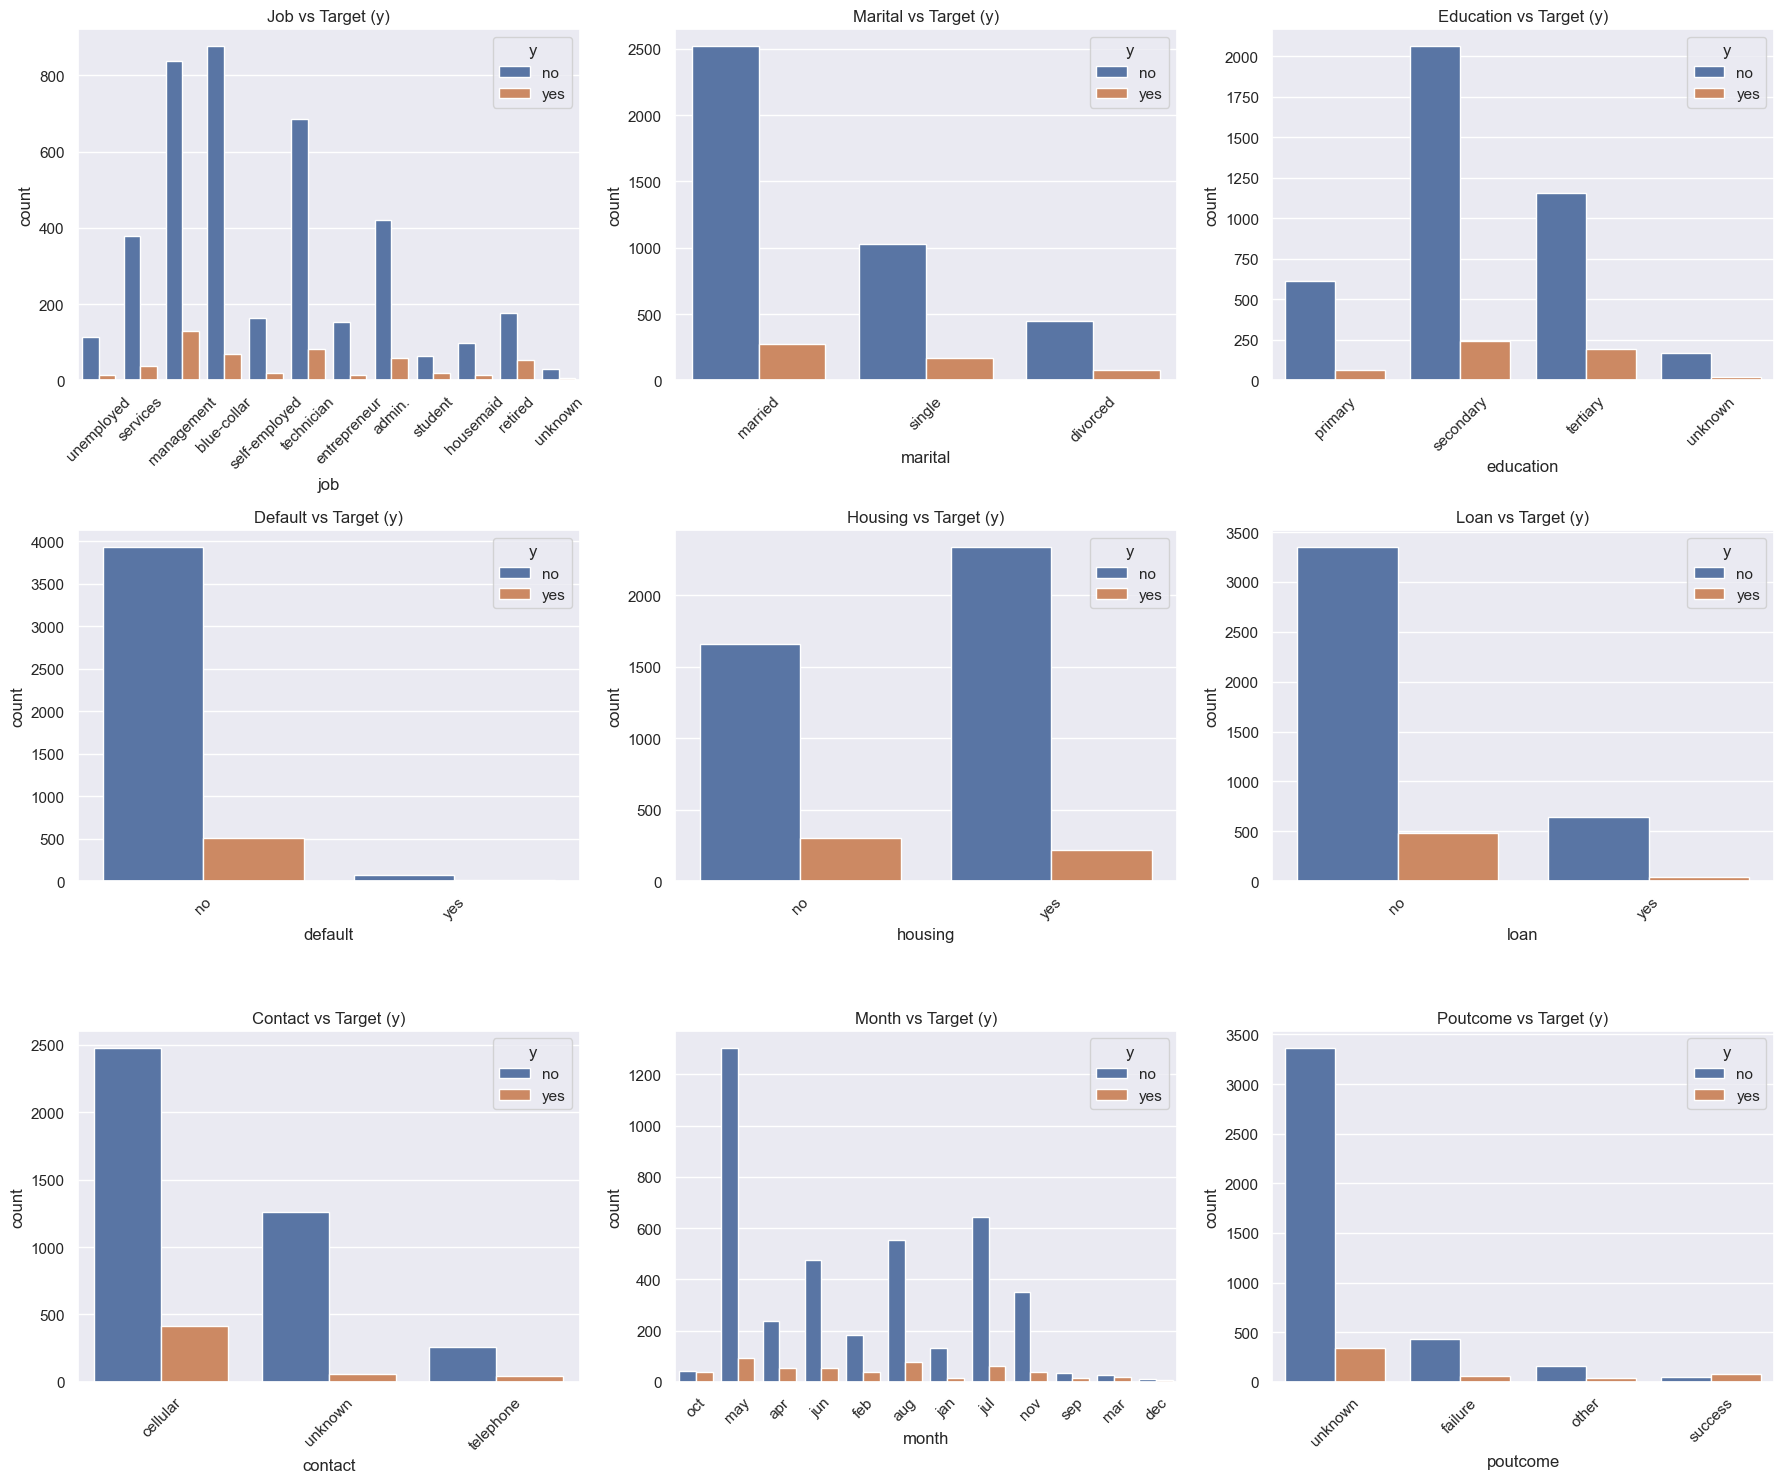

In [18]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='y', data=df, ax=axes[i])
    axes[i].set_title(f'{col.capitalize()} vs Target (y)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Multivariate Analysis

#### Aggregated Statistics of Balance, Age, and Duration by Job Category

In [20]:
grouped_data = df.groupby('job').agg({
    'balance': ['mean', 'count'],
    'age': ['mean', 'max'],
    'duration': 'sum'
}).reset_index()

In [21]:
grouped_data

job      balance              age     duration
                          mean count       mean max      sum
0          admin.  1226.736402   478  39.682008  66   112172
1     blue-collar  1085.161734   946  40.156448  75   263141
2    entrepreneur  1645.125000   168  42.011905  63    47960
3       housemaid  2083.803571   112  47.339286  80    32775
4      management  1766.928793   969  40.540764  80   252460
5         retired  2319.191304   230  61.869565  87    65701
6   self-employed  1392.409836   183  41.453552  62    48335
7        services  1103.956835   417  38.570743  60   109457
8         student  1543.821429    84  26.821429  42    20890
9      technician  1330.996094   768  39.470052  71   193673
10     unemployed  1089.421875   128  40.906250  60    38562
11        unknown  1501.710526    38  48.105263  71     8243

#### Heatmap of Mean Balance, Count, Mean Age, Max Age, and Total Duration by Job Category

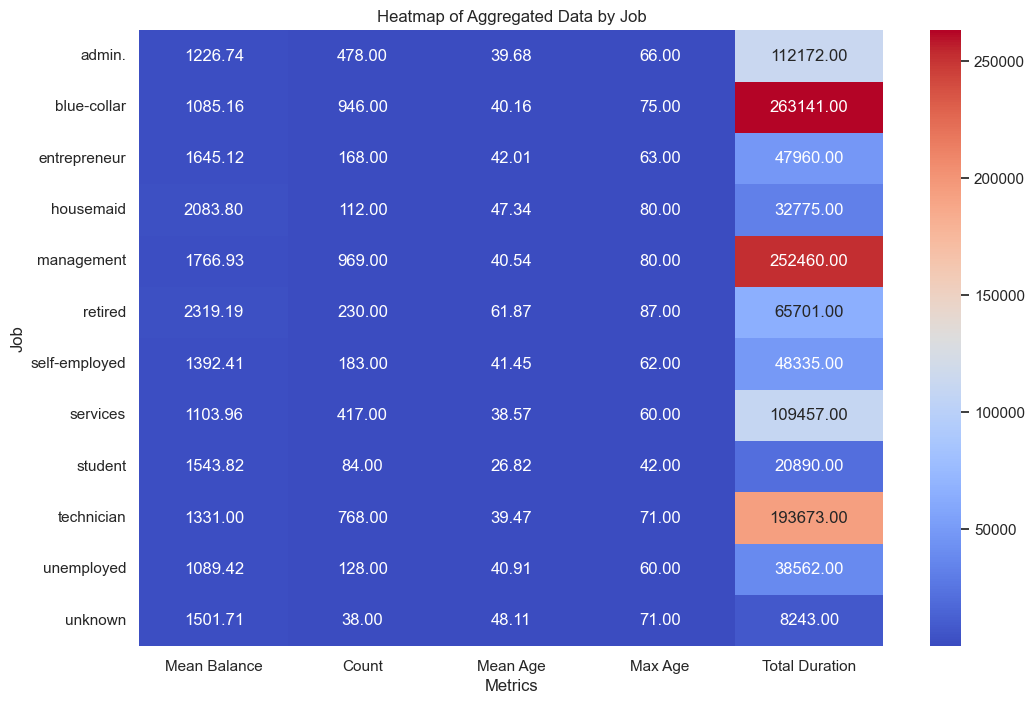

In [22]:
grouped_multiple.columns = ['Job', 'Mean Balance', 'Count', 'Mean Age', 'Max Age', 'Total Duration']
grouped_multiple.set_index('Job', inplace=True)
plt.figure(figsize=(12, 8))
sns.heatmap(grouped_multiple, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap of Aggregated Data by Job')
plt.xlabel('Metrics')
plt.ylabel('Job')
plt.show()

#### Correlation Matrix of Numerical Features

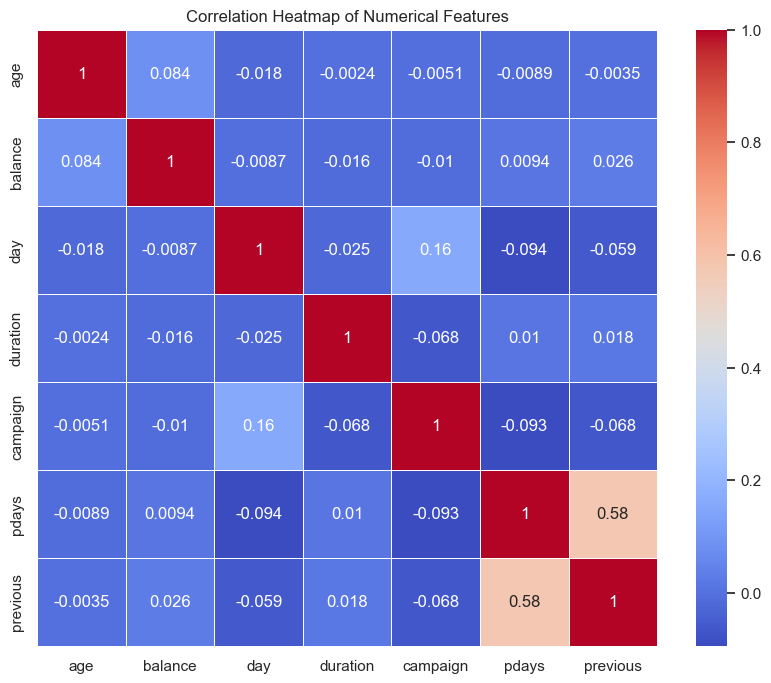

In [23]:
df_num = df[num]

# Calculate the correlation matrix
corr_matrix = df_num.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

#### Relationships Among Numeric Features with Target Variable

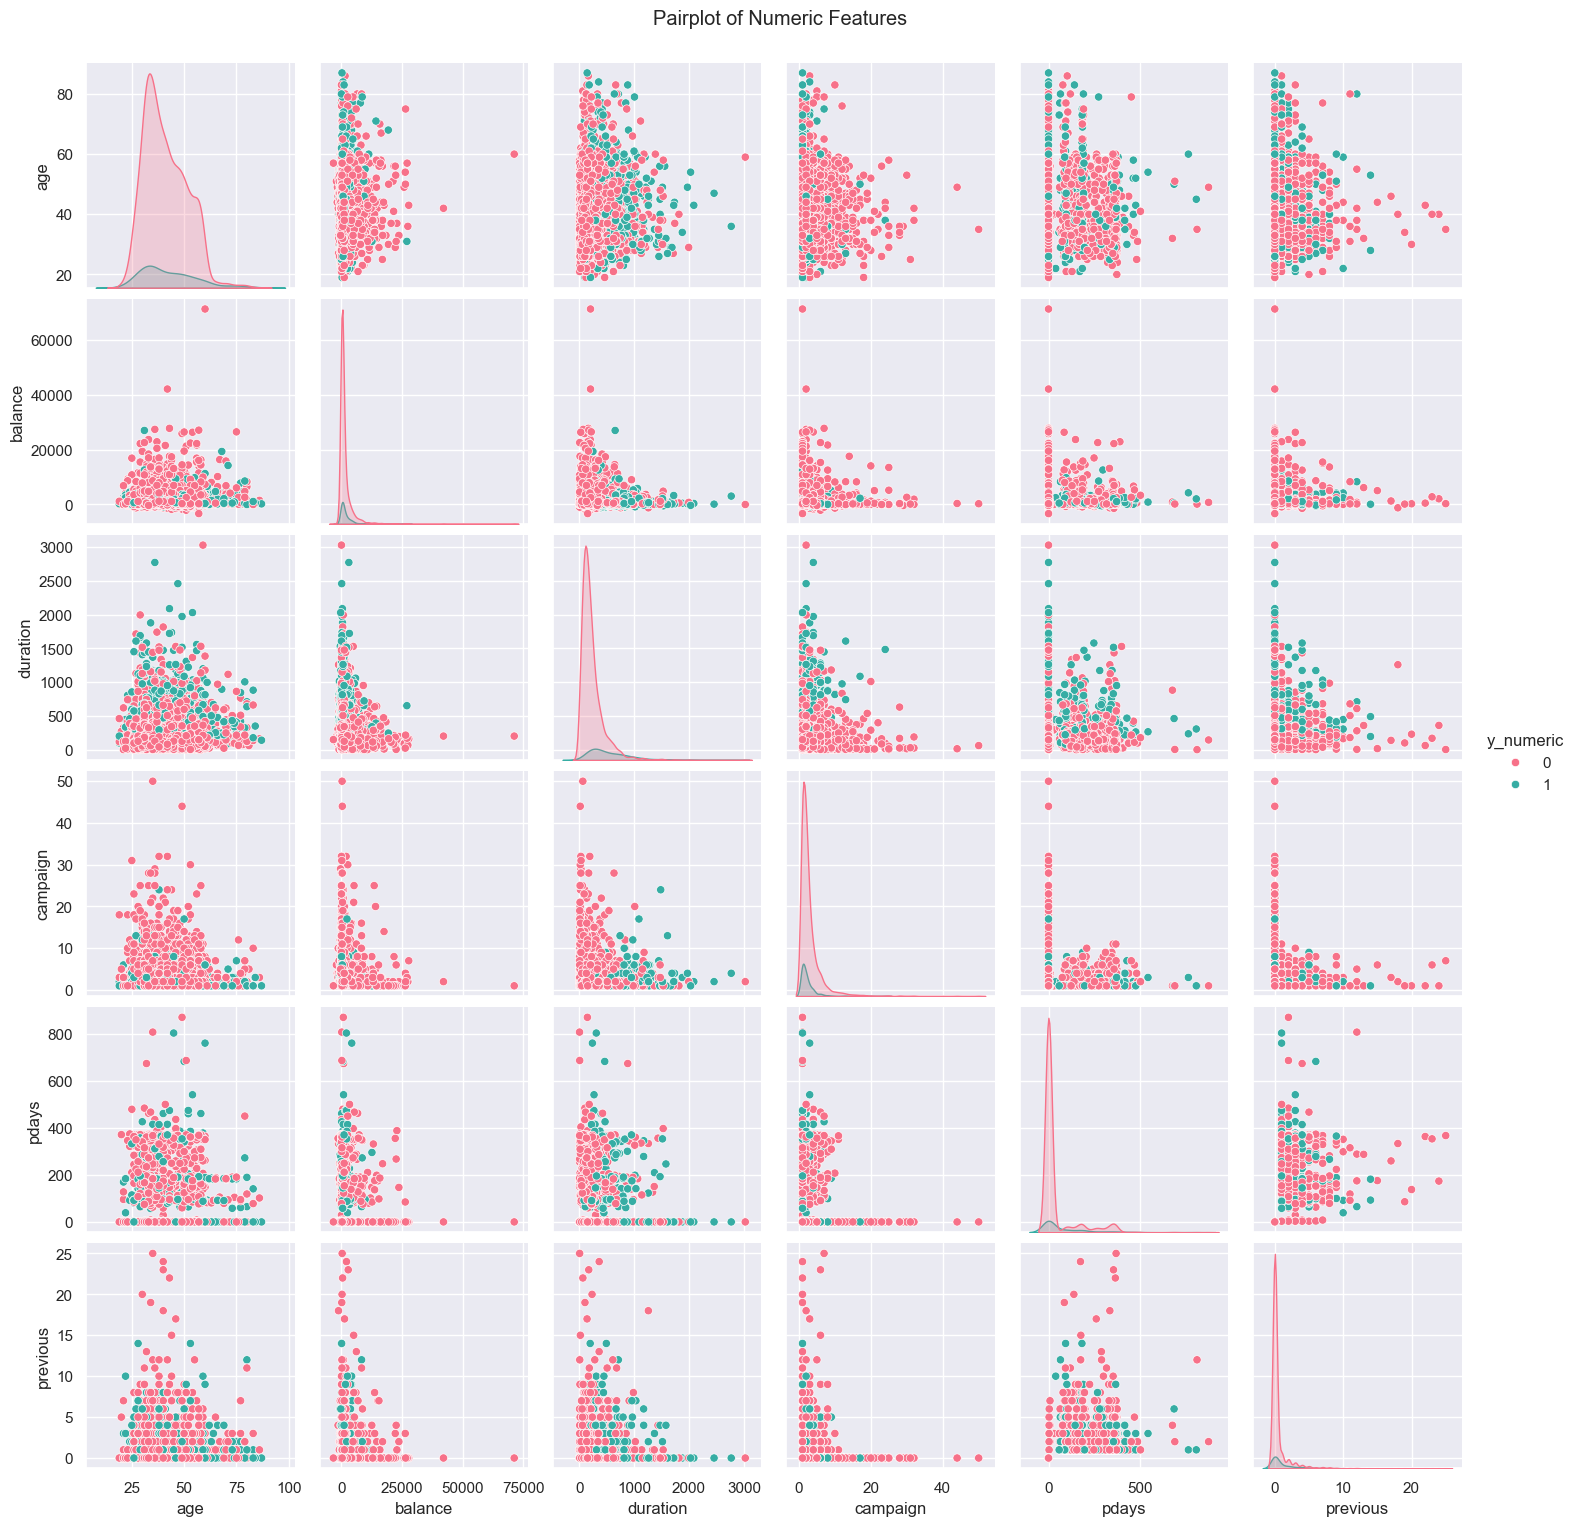

In [24]:
df['y_numeric'] = df['y'].map({'yes': 1, 'no': 0})
numeric_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'y_numeric']
sns.pairplot(df[numeric_features], hue='y_numeric', diag_kind='kde', palette='husl')
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()

## Data Preparation

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
 17  y_numeric  4521 non-null   int64 
dtypes: int64(8), object(10)
memory usage: 635.9+ KB


In [26]:
cat.pop()

'y'

In [27]:
df['poutcome'].value_counts()

poutcome
unknown    3705
failure     490
other       197
success     129
Name: count, dtype: int64

In [28]:
cat

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [29]:
new_df = pd.get_dummies(df[cat])

In [30]:
new_df

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
1,False,False,False,False,False,False,False,True,False,False,...,False,False,True,False,False,False,True,False,False,False
2,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
4,False,True,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
4517,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4518,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
4519,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [31]:
df.drop(cat, axis=1, inplace= True)

In [32]:
df = df.join(new_df)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 53 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   age                  4521 non-null   int64 
 1   balance              4521 non-null   int64 
 2   day                  4521 non-null   int64 
 3   duration             4521 non-null   int64 
 4   campaign             4521 non-null   int64 
 5   pdays                4521 non-null   int64 
 6   previous             4521 non-null   int64 
 7   y                    4521 non-null   object
 8   y_numeric            4521 non-null   int64 
 9   job_admin.           4521 non-null   bool  
 10  job_blue-collar      4521 non-null   bool  
 11  job_entrepreneur     4521 non-null   bool  
 12  job_housemaid        4521 non-null   bool  
 13  job_management       4521 non-null   bool  
 14  job_retired          4521 non-null   bool  
 15  job_self-employed    4521 non-null   bool  
 16  job_se

In [34]:
X = df.drop('y', axis= 1)

In [35]:
y = df['y']

In [36]:
from sklearn.model_selection import train_test_split 

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 30, test_size= .25, stratify= y)

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [39]:
lr = LogisticRegression(random_state= 20)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

C:\Users\Aruys_Jr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [40]:
rf = RandomForestClassifier(random_state=20)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [41]:
fi = pd.DataFrame({"Name":rf.feature_names_in_,"Importance":rf.feature_importances_})

In [42]:
fi

,Name,Importance
0,age,0.027126
1,balance,0.022037
2,day,0.018224
3,duration,0.104902
4,campaign,0.008554
5,pdays,0.015757
6,previous,0.010252
7,y_numeric,0.649675
8,job_admin.,0.002264
9,job_blue-collar,0.002467


In [43]:
from sklearn.metrics import accuracy_score, classification_report, precision_score, f1_score, recall_score

In [44]:
def metrics(y_test, pred) :
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, pos_label='yes')
    pr = precision_score(y_test, pred, pos_label='yes')
    rc = recall_score(y_test, pred, pos_label='yes')
    return (acc, f1, pr, rc)

In [45]:
lr_acc, lr_f1, lr_pr, lr_rc = metrics(y_test, lr_pred)

In [46]:
pd.crosstab(y_test, lr_pred)

col_0,no,yes
y,,
no,965,36
yes,64,66


In [47]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

          no       0.94      0.96      0.95      1001
         yes       0.65      0.51      0.57       130

    accuracy                           0.91      1131
   macro avg       0.79      0.74      0.76      1131
weighted avg       0.90      0.91      0.91      1131



In [48]:
print(accuracy_score(y_test, rf_pred))

1.0


In [49]:
pd.crosstab(y_test,rf_pred)

col_0,no,yes
y,,
no,1001,0
yes,0,130


In [50]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

          no       1.00      1.00      1.00      1001
         yes       1.00      1.00      1.00       130

    accuracy                           1.00      1131
   macro avg       1.00      1.00      1.00      1131
weighted avg       1.00      1.00      1.00      1131



In [51]:
rf_acc, rf_f1, rf_pr, rf_rc = metrics(y_test, rf_pred)

In [52]:
score = [lr_acc,rf_acc,lr_f1,rf_f1,lr_pr,rf_pr,lr_rc,rf_rc]
def met_df(scores):
    alg = ['LR','RF','LR','RF','LR','RF','LR','RF']
    met = ['Accuracy','Accuracy','F1_Score','F1_Score','Precision_Score','Precision_Score','Recall_Score','Recall_Score']

    base_met = pd.DataFrame({"Metrics":met,'Algorithm':alg, "Score":scores})
    return base_met

In [53]:
base_metrics = met_df(score)

In [54]:
base_metrics

,Metrics,Algorithm,Score
0,Accuracy,LR,0.911583
1,Accuracy,RF,1.000000
2,F1_Score,LR,0.568966
3,F1_Score,RF,1.000000
4,Precision_Score,LR,0.647059
5,Precision_Score,RF,1.000000
6,Recall_Score,LR,0.507692
7,Recall_Score,RF,1.000000


C:\Users\Aruys_Jr\AppData\Local\Temp\ipykernel_13760\1344766805.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  barplot.set_xticklabels(barplot.get_xticklabels(), fontsize=14)


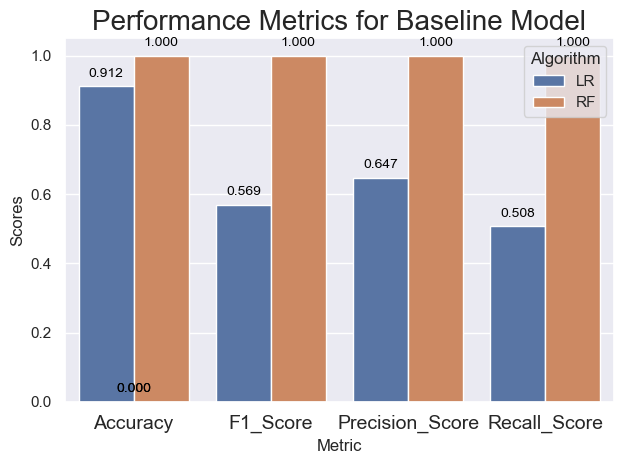

In [55]:
barplot = sns.barplot(data= base_metrics, x='Metrics', y='Score',hue='Algorithm')
#plt.xticks(rotation=90)
# Adding title and labels
plt.title('Performance Metrics for Baseline Model', fontsize=20)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Scores', fontsize=12)

# Adding scores on each bar
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.3f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 9),
                     textcoords='offset points',
                     fontsize=10,
                     color='black')

# Enlarging the model names
barplot.set_xticklabels(barplot.get_xticklabels(), fontsize=14)


# Showing the plot
plt.tight_layout()
plt.show()

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 53 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   age                  4521 non-null   int64 
 1   balance              4521 non-null   int64 
 2   day                  4521 non-null   int64 
 3   duration             4521 non-null   int64 
 4   campaign             4521 non-null   int64 
 5   pdays                4521 non-null   int64 
 6   previous             4521 non-null   int64 
 7   y                    4521 non-null   object
 8   y_numeric            4521 non-null   int64 
 9   job_admin.           4521 non-null   bool  
 10  job_blue-collar      4521 non-null   bool  
 11  job_entrepreneur     4521 non-null   bool  
 12  job_housemaid        4521 non-null   bool  
 13  job_management       4521 non-null   bool  
 14  job_retired          4521 non-null   bool  
 15  job_self-employed    4521 non-null   bool  
 16  job_se

In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
#X = df[["duration","age",'balance','campaign','pdays','day','previous','housing_no','housing_yes','contact_cellular','contact_unknown']]

In [59]:
cat_age = []
for i in df['age'] :
    if i <=50 :
        cat_age.append("young")
    else :
        cat_age.append("old")
X['cat_age'] = cat_age

In [60]:
X['cat_age'].value_counts()

cat_age
young    3594
old       927
Name: count, dtype: int64

In [61]:
ag = pd.get_dummies(X['cat_age'])
X.drop('cat_age', axis=1, inplace= True)
X = X.join(ag)

In [62]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 54 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  4521 non-null   int64
 1   balance              4521 non-null   int64
 2   day                  4521 non-null   int64
 3   duration             4521 non-null   int64
 4   campaign             4521 non-null   int64
 5   pdays                4521 non-null   int64
 6   previous             4521 non-null   int64
 7   y_numeric            4521 non-null   int64
 8   job_admin.           4521 non-null   bool 
 9   job_blue-collar      4521 non-null   bool 
 10  job_entrepreneur     4521 non-null   bool 
 11  job_housemaid        4521 non-null   bool 
 12  job_management       4521 non-null   bool 
 13  job_retired          4521 non-null   bool 
 14  job_self-employed    4521 non-null   bool 
 15  job_services         4521 non-null   bool 
 16  job_student          452

In [63]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [64]:
X_scaled = pd.DataFrame(X_scaled, columns= X.columns)

In [65]:
X_scaled

,age,balance,day,duration,campaign,pdays,previous,y_numeric,job_admin.,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,old,young
0,-1.056270,0.121072,0.374052,-0.711861,-0.576829,-0.407218,-0.320413,-0.360902,-0.343844,-0.514408,...,-0.669064,-0.306828,7.450671,-0.107869,-0.348652,-0.213447,-0.171381,0.469300,-0.507868,0.507868
1,-0.772583,1.118644,-0.596026,-0.169194,-0.576829,2.989044,2.041734,-0.360902,-0.343844,-0.514408,...,1.494626,-0.306828,-0.134216,-0.107869,2.868193,-0.213447,-0.171381,-2.130831,-0.507868,0.507868
2,-0.583458,-0.024144,0.010273,-0.303898,-0.576829,2.899143,0.270124,-0.360902,-0.343844,-0.514408,...,-0.669064,-0.306828,-0.134216,-0.107869,2.868193,-0.213447,-0.171381,-2.130831,-0.507868,0.507868
3,-1.056270,0.017726,-1.566105,-0.250017,0.387967,-0.407218,-0.320413,-0.360902,-0.343844,-0.514408,...,-0.669064,-0.306828,-0.134216,-0.107869,-0.348652,-0.213447,-0.171381,0.469300,-0.507868,0.507868
4,1.686036,-0.472753,-1.323585,-0.146102,-0.576829,-0.407218,-0.320413,-0.360902,-0.343844,1.943983,...,1.494626,-0.306828,-0.134216,-0.107869,-0.348652,-0.213447,-0.171381,0.469300,1.969016,-1.969016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,-0.772583,-0.583410,1.707910,0.250315,0.709566,-0.407218,-0.320413,-0.360902,-0.343844,-0.514408,...,-0.669064,-0.306828,-0.134216,-0.107869,-0.348652,-0.213447,-0.171381,0.469300,-0.507868,0.507868
4517,1.496912,-1.573671,-0.838546,-0.427057,-0.576829,-0.407218,-0.320413,-0.360902,-0.343844,-0.514408,...,1.494626,-0.306828,-0.134216,-0.107869,-0.348652,-0.213447,-0.171381,0.469300,1.969016,-1.969016
4518,1.496912,-0.374724,0.374052,-0.434754,2.639160,-0.407218,-0.320413,-0.360902,-0.343844,-0.514408,...,-0.669064,-0.306828,-0.134216,-0.107869,-0.348652,-0.213447,-0.171381,0.469300,1.969016,-1.969016
4519,-1.245394,-0.094925,-1.202326,-0.519426,0.387967,1.710451,1.451197,-0.360902,-0.343844,1.943983,...,-0.669064,-0.306828,-0.134216,-0.107869,-0.348652,4.685001,-0.171381,-2.130831,-0.507868,0.507868


In [66]:
from imblearn.over_sampling import SMOTE

In [67]:
smote = SMOTE(random_state=20)

In [68]:
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

In [69]:
len(X_resampled)

8000

In [70]:
X_rtrain, X_rtest, y_rtrain, y_rtest = train_test_split(X_resampled, y_resampled, random_state= 30, test_size= .25, stratify= y_resampled)

In [71]:
lr = LogisticRegression(random_state= 20)
lr.fit(X_rtrain, y_rtrain)
lr_pred = lr.predict(X_rtest)

In [72]:
rf = RandomForestClassifier(random_state=20)
rf.fit(X_rtrain, y_rtrain)
rf_pred = rf.predict(X_rtest)

In [73]:
fi = pd.DataFrame({"Name":rf.feature_names_in_,"Importance":rf.feature_importances_})

In [74]:
fi

,Name,Importance
0,age,0.009689
1,balance,0.013453
2,day,0.008754
3,duration,0.162463
4,campaign,0.012830
5,pdays,0.011148
6,previous,0.013248
7,y_numeric,0.553471
8,job_admin.,0.001714
9,job_blue-collar,0.004853


In [75]:
print(accuracy_score(y_rtest, lr_pred))

1.0


In [76]:
pd.crosstab(y_rtest, lr_pred)

col_0,no,yes
y,,
no,1000,0
yes,0,1000


<Axes: xlabel='col_0', ylabel='y'>

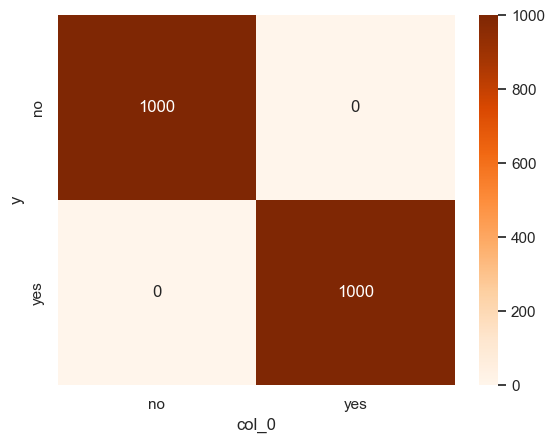

In [77]:
sns.heatmap(pd.crosstab(y_rtest,lr_pred), annot= True, fmt='d', cmap="Oranges")

In [78]:
print(classification_report(y_rtest, lr_pred))

              precision    recall  f1-score   support

          no       1.00      1.00      1.00      1000
         yes       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [79]:
print(accuracy_score(y_rtest, rf_pred))

1.0


In [80]:
pd.crosstab(y_rtest,rf_pred)

col_0,no,yes
y,,
no,1000,0
yes,0,1000


In [81]:
print(classification_report(y_rtest,rf_pred))

              precision    recall  f1-score   support

          no       1.00      1.00      1.00      1000
         yes       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



<Axes: xlabel='col_0', ylabel='y'>

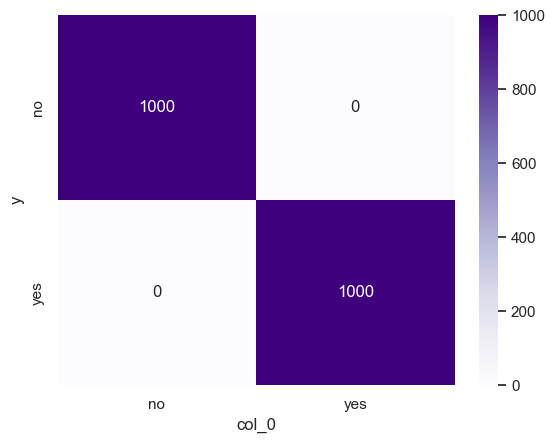

In [82]:
sns.heatmap(pd.crosstab(y_rtest, rf_pred), annot=True, fmt='d', cmap='Purples')

In [83]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold

In [84]:
param_rf = { 
	'n_estimators': [25, 50, 100, 150], 
	'max_features': ['sqrt', 'log2', None], 
	'max_depth': [3, 6, 9], 
	'max_leaf_nodes': [3, 6, 9], 
} 

In [85]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

In [86]:
rf_ran = RandomForestClassifier(random_state=4)

In [87]:
ran_rf = RandomizedSearchCV(estimator=rf_ran, param_distributions= param_rf, n_iter=5, cv=kf, n_jobs=-1, random_state= 23)

In [88]:
random_rf = ran_rf.fit(X_rtrain, y_rtrain)

In [89]:
print(f'Best parameters {random_rf.best_params_}')

Best parameters {'n_estimators': 100, 'max_leaf_nodes': 9, 'max_features': None, 'max_depth': 6}


In [90]:
random_rf.best_score_

1.0

In [91]:
best_model = random_rf.best_estimator_
accuracy = best_model.score(X_rtest,y_rtest)
print("Test Accuracy", accuracy)

Test Accuracy 1.0


In [92]:
rfp = RandomForestClassifier(n_estimators=150, max_leaf_nodes= 9, max_features= 'sqrt', max_depth= 6)

In [93]:
rfp.fit(X_rtrain, y_rtrain)

RandomForestClassifier(max_depth=6, max_leaf_nodes=9, n_estimators=150)

In [94]:
rfpred = rfp.predict(X_rtest)

In [95]:
print(accuracy_score(y_rtest, rfpred))

0.9995


In [96]:
pd.crosstab(y_rtest, rfpred)

col_0,no,yes
y,,
no,1000,0
yes,1,999


<Axes: xlabel='col_0', ylabel='y'>

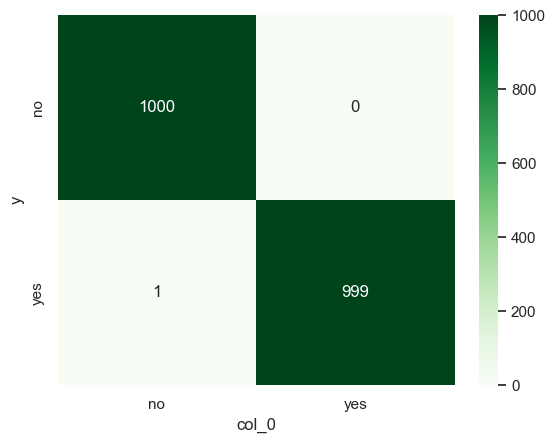

In [97]:
sns.heatmap(pd.crosstab(y_rtest, rfpred), annot=True, fmt='d', cmap="Greens")

In [98]:
param_lr = [
    {'penalty':['l1','l2','elasticnet','none'],
    'C' : np.logspace(-4,4,20),
    'solver': ['lbfgs','newton-cg','liblinear','sag','saga'],
    'max_iter'  : [100,1000,2500,5000]
}
]

In [99]:
lr_ran = LogisticRegression(random_state=4)

In [100]:
ran_lr = RandomizedSearchCV(estimator=lr_ran, param_distributions= param_lr, n_iter=5, cv=kf, n_jobs=-1, random_state= 23)

In [101]:
random_lr = ran_lr.fit(X_rtrain, y_rtrain)

C:\Users\Aruys_Jr\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
15 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Aruys_Jr\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Aruys_Jr\anaconda3\Lib\site-packages\sklearn\base.py", line 1467, in wrapper
    estimator._validate_params()
  File "C:\Users\Aruys_Jr\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\Aruys_Jr\anaconda3\Lib\

In [102]:
print(f'Best parameters {random_lr.best_params_}')

Best parameters {'solver': 'liblinear', 'penalty': 'l1', 'max_iter': 1000, 'C': 0.615848211066026}


In [103]:
random_lr.best_score_

1.0

In [104]:
best_model = random_lr.best_estimator_
accuracy = best_model.score(X_rtest,y_rtest)
print("Test Accuracy", accuracy)

Test Accuracy 1.0


In [105]:
lrp = LogisticRegression(solver='liblinear', penalty='l1', max_iter=1000, C=0.615848211066026)

In [106]:
lrp.fit(X_rtrain, y_rtrain)

LogisticRegression(C=0.615848211066026, max_iter=1000, penalty='l1',
                   solver='liblinear')

In [107]:
lrpred = lrp.predict(X_rtest)

In [108]:
print(accuracy_score(y_rtest, lrpred))

1.0


In [109]:
pd.crosstab(y_rtest, lrpred)

col_0,no,yes
y,,
no,1000,0
yes,0,1000


<Axes: xlabel='col_0', ylabel='y'>

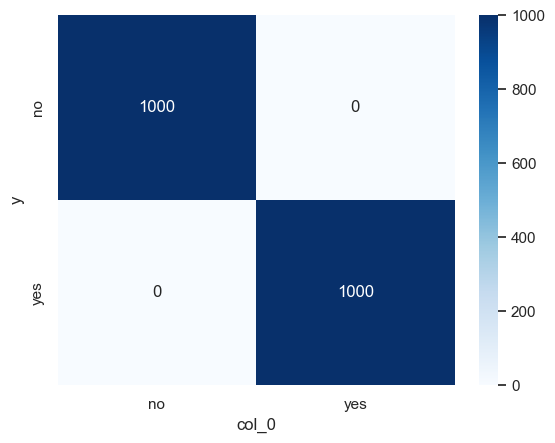

In [110]:
sns.heatmap(pd.crosstab(y_rtest, lrpred), annot= True,fmt='d', cmap="Blues")

In [111]:
rfacc, rff1, rfpr, rfrc = metrics(y_rtest, rfpred)
lracc, lrf1, lrpr, lrrc = metrics(y_rtest, lrpred)

In [112]:
im_score = [rfacc,lracc,rff1,lrf1,rfpr,lrpr,rfrc,lrrc]
im_metrics = met_df(im_score)

C:\Users\Aruys_Jr\AppData\Local\Temp\ipykernel_13760\3116554956.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  barplot.set_xticklabels(barplot.get_xticklabels(), fontsize=14)


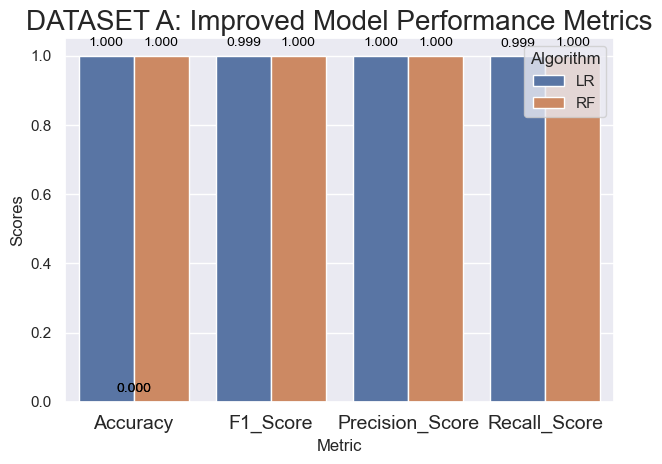

In [113]:
barplot = sns.barplot(data= im_metrics, x='Metrics', y='Score',hue='Algorithm')
#plt.xticks(rotation=90)
# Adding title and labels
plt.title('DATASET A: Improved Model Performance Metrics', fontsize=20)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Scores', fontsize=12)

# Adding scores on each bar
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.3f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 9),
                     textcoords='offset points',
                     fontsize=10,
                     color='black')

# Enlarging the model names
barplot.set_xticklabels(barplot.get_xticklabels(), fontsize=14)


# Showing the plot
plt.tight_layout()
plt.show()

In [114]:
b_data = []
for i in range(len(base_metrics)):
    b_data.append('Baseline')
base_metrics['Model type'] = b_data
im_data = []
for i in range(len(im_metrics)):
    im_data.append("Improved")
im_metrics['Model type'] = im_data

In [115]:
metrics_df = base_metrics.merge(im_metrics, how='outer')

In [116]:
metrics_df

,Metrics,Algorithm,Score,Model type
0,Accuracy,LR,0.911583,Baseline
1,Accuracy,LR,0.999500,Improved
2,Accuracy,RF,1.000000,Baseline
3,Accuracy,RF,1.000000,Improved
4,F1_Score,LR,0.568966,Baseline
5,F1_Score,LR,0.999500,Improved
6,F1_Score,RF,1.000000,Baseline
7,F1_Score,RF,1.000000,Improved
8,Precision_Score,LR,0.647059,Baseline
9,Precision_Score,LR,1.000000,Improved


C:\Users\Aruys_Jr\AppData\Local\Temp\ipykernel_13760\1897901281.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  barplot.set_xticklabels(barplot.get_xticklabels(), fontsize=14)


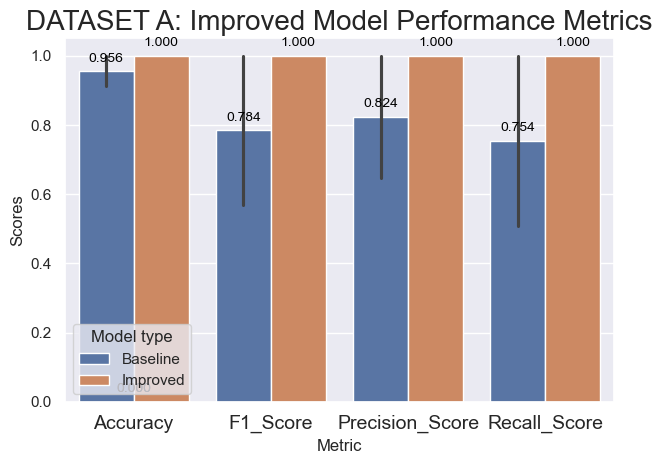

In [117]:
barplot = sns.barplot(data= metrics_df, x='Metrics', y='Score',hue='Model type')
#plt.xticks(rotation=90)
# Adding title and labels
plt.title('DATASET A: Improved Model Performance Metrics', fontsize=20)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Scores', fontsize=12)

# Adding scores on each bar
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.3f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 9),
                     textcoords='offset points',
                     fontsize=10,
                     color='black')

# Enlarging the model names
barplot.set_xticklabels(barplot.get_xticklabels(), fontsize=14)


# Showing the plot
plt.tight_layout()
plt.show()

C:\Users\Aruys_Jr\AppData\Local\Temp\ipykernel_13760\3404519590.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  barplot.set_xticklabels(barplot.get_xticklabels(), fontsize=14)


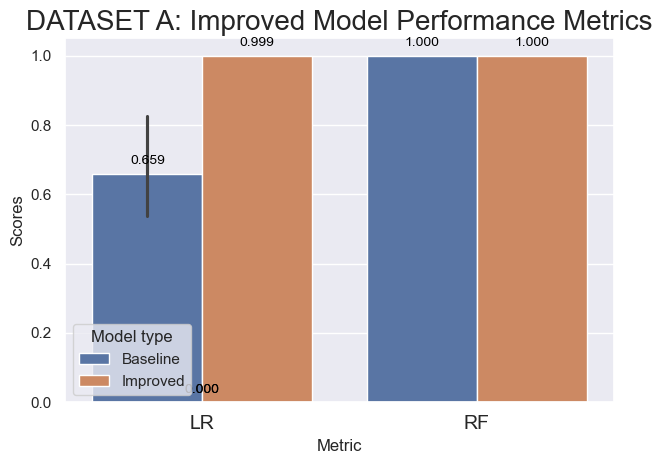

In [118]:
barplot = sns.barplot(data= metrics_df, x='Algorithm', y='Score',hue='Model type')
#plt.xticks(rotation=90)
# Adding title and labels
plt.title('DATASET A: Improved Model Performance Metrics', fontsize=20)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Scores', fontsize=12)

# Adding scores on each bar
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.3f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 9),
                     textcoords='offset points',
                     fontsize=10,
                     color='black')

# Enlarging the model names
barplot.set_xticklabels(barplot.get_xticklabels(), fontsize=14)


# Showing the plot
plt.tight_layout()
plt.show()